## First Innings

In [5]:
import pandas as pd
import joblib

In [6]:
delivery = pd.read_csv('..\data\deliveries_new.csv')
matches = pd.read_csv('..\data\matches_new.csv')

In [7]:
delivery['over'] = delivery['over'] + 1

In [8]:
delivery= delivery[delivery['inning']==1]

In [9]:
delivery = delivery.sort_values(['match_id', 'over', 'ball'])

In [10]:
delivery['current_score'] = (
    delivery.groupby('match_id')['total_runs'].cumsum()
)


In [11]:
delivery['legal_ball'] = delivery['extra_runs'] == 0

delivery['balls_bowled'] = (
    delivery[delivery['legal_ball']]
    .groupby('match_id')
    .cumcount() + 1
)

delivery['balls_bowled'] = delivery.groupby('match_id')['balls_bowled'].ffill()

In [12]:
delivery['ball_left'] = 120- delivery['balls_bowled']

In [13]:
delivery = delivery[delivery['ball_left'] > 0]

In [14]:
delivery['is_wicket'] = (
    delivery['player_dismissed'].notna()
).astype(int)

delivery['total_wicket'] = (
    delivery.groupby('match_id')['is_wicket'].cumsum()
)


In [15]:
delivery['current_rr'] = (
    delivery['current_score']*6 /
    delivery['balls_bowled'].replace(0,1)
)

In [16]:
delivery.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'current_score', 'legal_ball',
       'balls_bowled', 'ball_left', 'total_wicket', 'current_rr'],
      dtype='object')

In [17]:
final_score = delivery.groupby('match_id')['current_score'].max()

In [18]:
delivery = delivery.merge(
    final_score.rename('final_score'),
    on='match_id'
)

In [19]:
X = delivery[['current_score','total_wicket','ball_left','current_rr']]
y = delivery['final_score']

In [20]:
from sklearn.ensemble import RandomForestRegressor
first_innings= RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
first_innings.fit(X , y)

joblib.dump(first_innings, '../models/first_innings.pkl')
joblib.dump(X.columns.tolist(), "../models/first_features.pkl")


['../models/first_features.pkl']

In [21]:
delivery['predicted_score'] = first_innings.predict(X)

In [22]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,dismissal_kind,fielder,current_score,legal_ball,balls_bowled,ball_left,total_wicket,current_rr,final_score,predicted_score
0,335982,1,KKR,RCB,1,2,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,1,True,1.0,119.0,0,6.000000,222,163.351590
1,335982,1,KKR,RCB,1,3,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,2,False,1.0,119.0,0,12.000000,222,168.328123
2,335982,1,KKR,RCB,1,4,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,2,True,2.0,118.0,0,6.000000,222,163.440218
3,335982,1,KKR,RCB,1,5,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,2,True,3.0,117.0,0,4.000000,222,164.494350
4,335982,1,KKR,RCB,1,6,BB McCullum,P Kumar,SC Ganguly,0,...,NaN,NaN,2,True,4.0,116.0,0,3.000000,222,162.130444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134809,1426312,1,SRH,KKR,18,5,JD Unadkat,SP Narine,PJ Cummins,0,...,lbw,NaN,113,True,104.0,16.0,9,6.519231,113,122.715650
134810,1426312,1,SRH,KKR,18,6,B Kumar,SP Narine,PJ Cummins,0,...,NaN,NaN,113,True,105.0,15.0,9,6.457143,113,122.981151
134811,1426312,1,SRH,KKR,19,1,PJ Cummins,AD Russell,B Kumar,0,...,NaN,NaN,113,True,106.0,14.0,9,6.396226,113,121.953924
134812,1426312,1,SRH,KKR,19,2,PJ Cummins,AD Russell,B Kumar,0,...,NaN,NaN,113,True,107.0,13.0,9,6.336449,113,119.748429


In [23]:
delivery = delivery.merge(
    matches[['id','winner']],
    left_on='match_id',
    right_on='id'
)

In [24]:
delivery['batting_team_won'] = (delivery['batting_team'] == delivery['winner']).astype(int)

In [25]:
final_delivery = delivery.drop_duplicates('match_id')

In [26]:
win_prob_table = (final_delivery.groupby('final_score')['batting_team_won'].mean())

In [27]:
delivery['win_probability'] = (
    delivery['predicted_score']
    .round()
    .map(win_prob_table)
    .fillna(method='ffill')
    .fillna(0.5)
)

C:\Users\hazra\AppData\Local\Temp\ipykernel_7388\249993399.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  delivery['predicted_score']


In [28]:
delivery['win_probability'] = (
    delivery.groupby('match_id')['win_probability']
       .ffill()
)


In [29]:
delivery

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,balls_bowled,ball_left,total_wicket,current_rr,final_score,predicted_score,id,winner,batting_team_won,win_probability
0,829705,1,MI,KKR,1,1,RG Sharma,UT Yadav,AJ Finch,0,...,1.0,119.0,0,0.000000,168,165.356031,829705,KKR,0,0.300000
1,829705,1,MI,KKR,1,2,RG Sharma,UT Yadav,AJ Finch,1,...,2.0,118.0,0,3.000000,168,163.118241,829705,KKR,0,0.666667
2,829705,1,MI,KKR,1,3,AJ Finch,UT Yadav,RG Sharma,1,...,3.0,117.0,0,4.000000,168,164.494350,829705,KKR,0,0.600000
3,829705,1,MI,KKR,1,4,RG Sharma,UT Yadav,AJ Finch,1,...,4.0,116.0,0,4.500000,168,164.679702,829705,KKR,0,0.300000
4,829705,1,MI,KKR,1,5,AJ Finch,UT Yadav,RG Sharma,0,...,4.0,116.0,0,6.000000,168,164.949308,829705,KKR,0,0.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71791,1426312,1,SRH,KKR,18,5,JD Unadkat,SP Narine,PJ Cummins,0,...,104.0,16.0,9,6.519231,113,122.715650,1426312,KKR,0,0.000000
71792,1426312,1,SRH,KKR,18,6,B Kumar,SP Narine,PJ Cummins,0,...,105.0,15.0,9,6.457143,113,122.981151,1426312,KKR,0,0.000000
71793,1426312,1,SRH,KKR,19,1,PJ Cummins,AD Russell,B Kumar,0,...,106.0,14.0,9,6.396226,113,121.953924,1426312,KKR,0,1.000000
71794,1426312,1,SRH,KKR,19,2,PJ Cummins,AD Russell,B Kumar,0,...,107.0,13.0,9,6.336449,113,119.748429,1426312,KKR,0,0.000000


In [30]:
live_match= delivery[delivery['match_id']== 1]
live_match[['current_score','total_wicket','ball_left','current_rr']]


,current_score,total_wicket,ball_left,current_rr


In [31]:
delivery.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder', 'current_score', 'legal_ball',
       'balls_bowled', 'ball_left', 'total_wicket', 'current_rr',
       'final_score', 'predicted_score', 'id', 'winner', 'batting_team_won',
       'win_probability'],
      dtype='object')

In [32]:

live_match[['balls_bowled','current_score','predicted_score','win_probability','current_rr']]

,balls_bowled,current_score,predicted_score,win_probability,current_rr


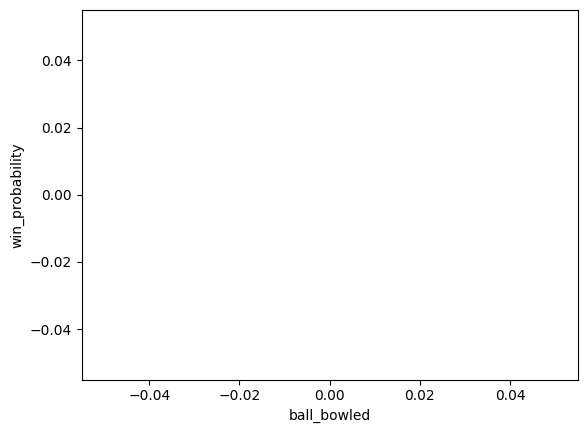

In [33]:
import matplotlib.pyplot as plt
plt.plot(live_match['balls_bowled'],live_match['win_probability']*100)
plt.xlabel('ball_bowled')
plt.ylabel('win_probability')
plt.show()